# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [2]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [3]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
print(df.isna().mean())
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = [
    "class",
    "who",
    "adult_male",
    "deck",
    "embark_town",
    "alive",
    "alone"
]      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns=leaky)
# print("Các cột còn lại:", list(df.columns))
print(list(df.columns))

survived       0.000000
pclass         0.000000
sex            0.000000
age            0.198653
sibsp          0.000000
parch          0.000000
fare           0.000000
embarked       0.002245
class          0.000000
who            0.000000
adult_male     0.000000
deck           0.772166
embark_town    0.002245
alive          0.000000
alone          0.000000
dtype: float64
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*Cột 'alive' chính là một cách nói khác của cột 'survive'. Khi mô hình thấy alive = true đồng nghĩa với survive = 1. Điều này khiến mô hình chỉ cần đọc cột alive là sẽ biết đáp án mà không cần học mối quan hệ của các cột khác và khiến mô hình học theo một cách gian lận mà không thật sự dự đoán dựa trên label như thông thường. Cuối cùng mô hình sẽ có accuracy gần như 100% trong tập test nhưng khi đưa vào thực tế không có cột alive nữa thì mô hình sẽ hoàn toàn vô dụng.*

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [4]:
# TODO 2: shape, info, describe
print( df.shape)
print("Target:", "survived")
print("\n=== DataFrame Info ===")

df.info()

print("\n=== Numerical Features ===")
print(df.describe())

print("\n=== Categorical Features ===")
print(df.describe(include="object"))

(891, 8)
Target: survived

=== DataFrame Info ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    str    
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB

=== Numerical Features ===
         survived      pclass         age       sibsp       parch        fare
count  891.000000  891.000000  714.000000  891.000000  891.000000  891.000000
mean     0.383838    2.308642   29.699118    0.523008    0.381594   32.204208
std      0.486592    0.836071   14.526497    1.102743    0.806057   49.693429
min      0.000000    1.000000    0.420000    0.000000    0.000000   

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_12208\3549620640.py:12: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(df.describe(include="object"))


**Trả lời 2 (biến số vs biến phân loại):**

*Biến số chính là cột survived, pclass, age, sibsp, parch, fare còn biến mục tiêu là cột sex và embarked*

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [5]:
# TODO 3: bảng missing (count + %)
missing = pd.DataFrame({
    "count": df.isna().sum(),
    "%": (df.isna().mean()*100).round(2)
    })
print(missing)


          count      %
survived      0   0.00
pclass        0   0.00
sex           0   0.00
age         177  19.87
sibsp         0   0.00
parch         0   0.00
fare          0   0.00
embarked      2   0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|------|---------:|-------------------|--------|
| age | 19.87% | Điền **median** | `age` là biến số và có outlier nên dùng median thay vì mean. |
| embarked | 0.22% | Điền **mode** | `embarked` là biến phân loại nên điền mode. |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [6]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    s = s.dropna()
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 -Q1
    botttom_outlier = Q1 - 1.5*IQR
    top_outlier = Q3+1.5*IQR
        # trả về số lượng outlier theo IQR
    return((s<botttom_outlier)| (s>top_outlier)).sum()
def dem_outlier_zscore(s, nguong=3.0):
    s = s.dropna()
    z = np.abs(stats.zscore(s))
        # trả về số lượng outlier theo Z-score
    return (z>nguong).sum()
# for col in ["age", "fare"]:
#     ...
for col in ["age", "fare"]:
    print(f"{col}")
    print("IQR:", dem_outlier_iqr(df[col]))
    print("Z_score:", dem_outlier_zscore(df[col]))

age
IQR: 11
Z_score: 2
fare
IQR: 116
Z_score: 20


**Trả lời 4 (quyết định với outlier của `fare`):**

*đối với các outlier của fare em lựa chọn dữ lại. Vì outlier này là outlier dữ liệu thực tế chứ không phải là lỗi. Nó phản ánh những khách hàng mua vé hạng nhất. Nếu bỏ đi nó sẽ làm mất đi thông tin quan trọng về sự khác biệt giữa các hạng vé ảnh hưởng đến khả năng dự đoán tỉ lệ sống sót.*

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

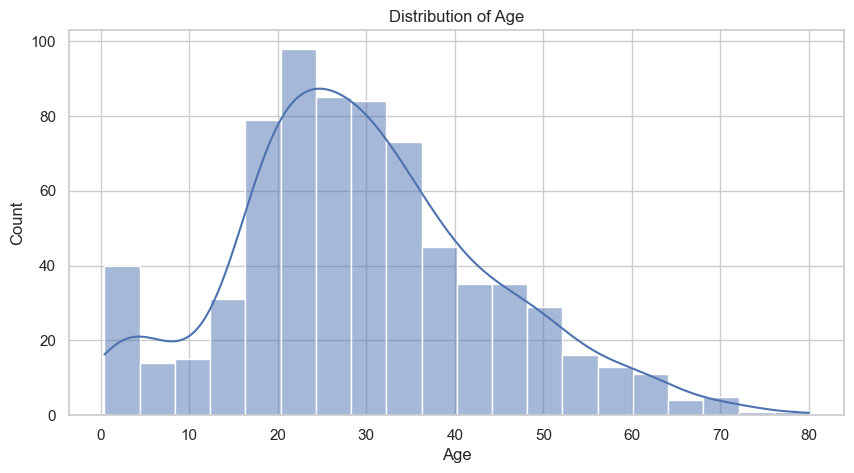

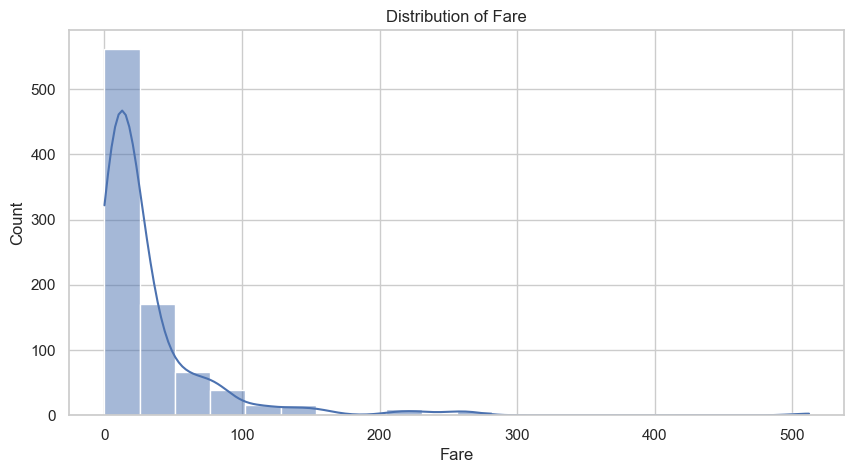

In [7]:
# TODO 5a: Histogram age & fare
plt.figure(figsize=(10,5))
sns.histplot(df["age"], bins=20, kde=True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(df["fare"], bins=20, kde=True)
plt.title("Distribution of Fare")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

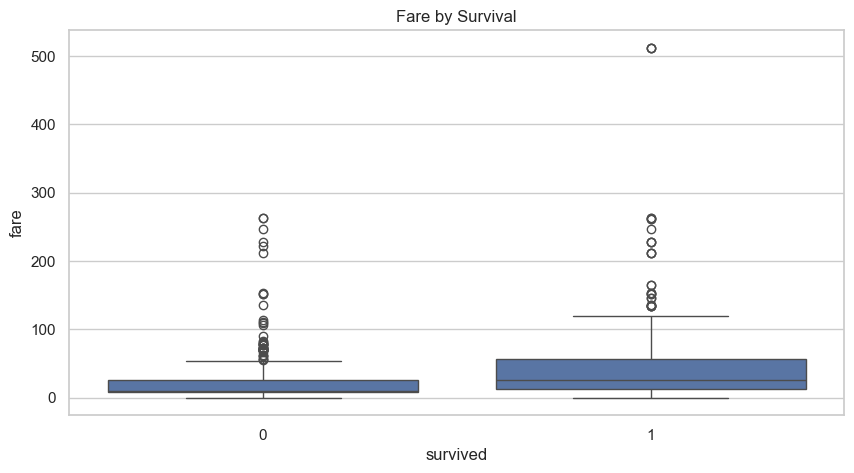

In [8]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Fare by Survival")
plt.show()

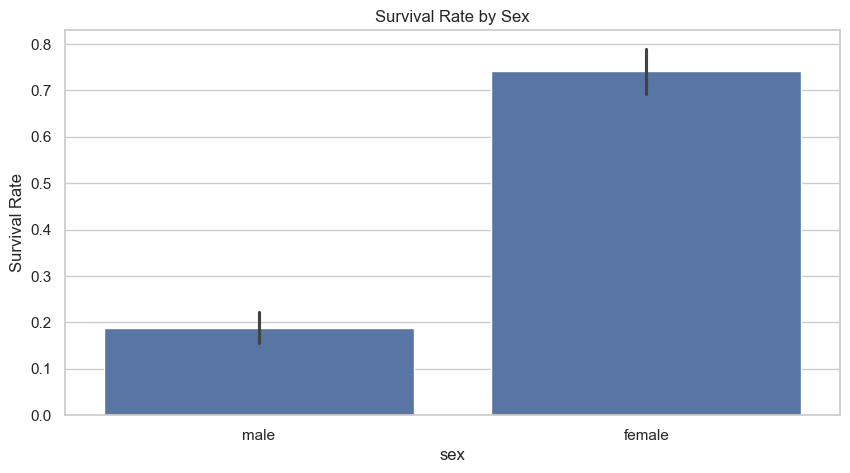

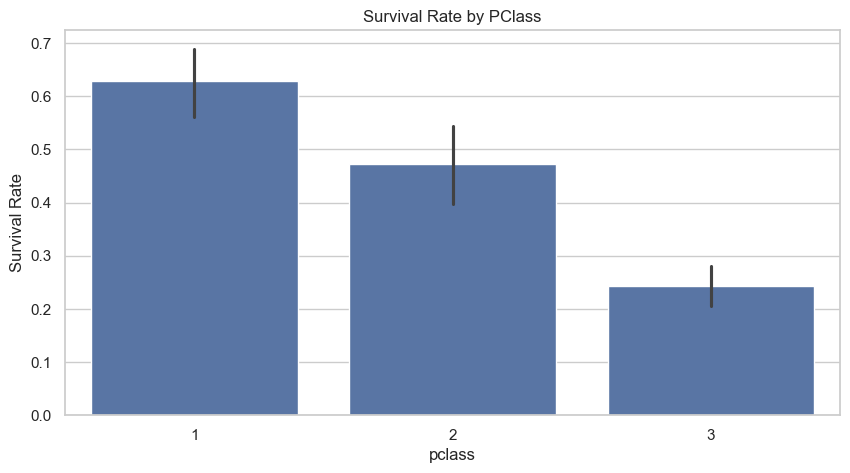

sex
female    74.203822
male      18.890815
Name: survived, dtype: float64


In [9]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(data=df, x="pclass", y="survived")
plt.title("Survival Rate by PClass")
plt.ylabel("Survival Rate")
plt.show()
print(df.groupby("sex")["survived"].mean()*100)

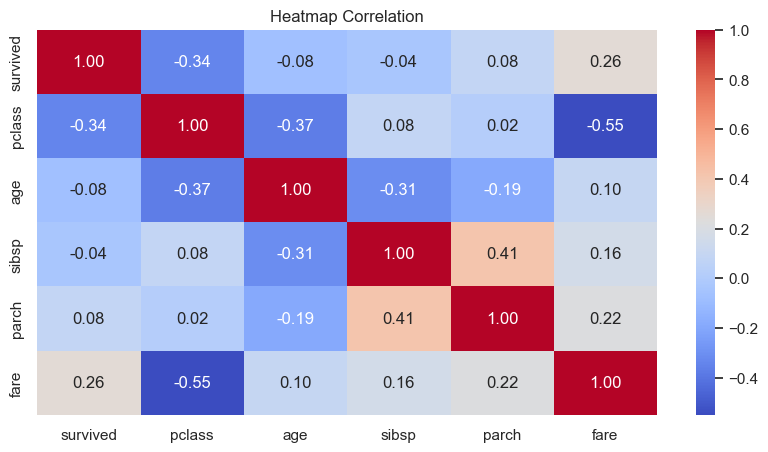

In [10]:
# TODO 5d: Heatmap correlation
plt.figure(figsize=(10,5))

corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Heatmap Correlation")
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: age có phân phối gần phân phối chuẩn và hơi lệch phải, chứng tỏ khách khá trẻ từ khoảng 20-40 tuổi. fare thì lệch phải rất mạnh, điều này hợp lý khi đa số hành khách mua vé giá thấp, chỉ số ít người mới mua được vé cao cấp.
- Boxplot: Ta thấy box rất nhỏ và outlier dày đặc nhưng nhóm sống sót vẫn có median cao hơn nhóm không sống sót. chứng tó giá vé cũng phần nào ảnh hưởng đến tỉ lệ sống sót của hành khách.
- Bar survival: Ta thấy tỉ lệ sống sót của nữ lên đến 74% và nam chỉ có 18.89% thấp hơn rất nhiều. Điều này đúng với thực tế rằng khi tàu titanic chìm thì hành khách nam thường nhường chỗ cho hành khách nữ lên tàu cứu hộ. Tương tự với hành khách ở hạng 1 cũng có tỉ lệ sống sót cao nhất rồi giảm dần đến hạng 3.
- Heatmap: ta thấy fare và pclass có tương quan âm khá mạnh, tức là khi pclass càng nhỏ(túc là hạng vé càng cao cấp) thì fare là giá vé sẽ càng cao. còn survived có tương quan dương với fare và tương quan âm với pclass cũng tương tự khi hạng vé càng sang thì càng và giá vé càng đắt thì có khả năng sông sót càng cao.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [11]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns="survived")
y = df["survived"]

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
X_tmp, X_test, y_tmp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify = y
)
# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_val, y_train, y_val = train_test_split(
    X_tmp,
    y_tmp,
    test_size=15/85,
    stratify=y_tmp
)
# print("Train/Val/Test:", ...)
print("Train:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)
# in tỷ lệ survived từng tập
print(f"Train: {y_train.mean()*100:.3f}")
print(f"Validation: {y_val.mean()*100:.3f}")
print(f"Test: {y_test.mean()*100:.3f}")

Train: (623, 7) (623,)
Validation: (134, 7) (134,)
Test: (134, 7) (134,)
Train: 38.363
Validation: 38.806
Test: 38.060


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [12]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    # ("onehot",  ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("num", pipe_so, num_cols),
    ("cat", pipe_cat, cat_cols),
    ("ord", "passthrough", ord_cols)
])

# preprocess.fit(X_train)
preprocess.fit(X_train)               # # fit CHỈ trên train
# X_train_t = preprocess.transform(X_train)
X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_val_t = preprocess.transform(X_val)
X_test_t = preprocess.transform(X_test)
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
print(X_train_t.shape, list(preprocess.get_feature_names_out()))

(623, 10) ['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*khi điền các giá trị như median, hay xài chuẩn hóa robustscaler thì mô hình sẽ học tham số từ data, nếu ta fit trên toàn dữ liệu thì các tham số sẽ vô tình sử dụng data từ tập val và tập test khiến mô hình biết trước dữ liệu. Khi chỉ fit trên tập train rồi transform cho validation và test, mọi tham số đều được học từ dữ liệu huấn luyện. Điều này mô phỏng đúng quá trình sử dụng mô hình trên dữ liệu mới và giúp kết quả đánh giá khách quan, không bị data leakage.*

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [13]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
print((df["survived"].value_counts(normalize=True)*100).round(2))

survived
0    61.62
1    38.38
Name: proportion, dtype: float64


**Trả lời 8:**

1. biến mục tiêu survived mất cân bằng nhẹ với sống sót khoảng 38.38% và chết 61.62%.
2. Nếu ta chỉ nhìn vào accuracy thì sẽ bị đánh lừa khi dữ liệu quá mất cân bằng. Ví dụ nếu số hành khách sống sót là 99.99% thì mô hình sẽ luôn dự đoán là sống sót, mặc kệ sau đó có bao nhiêu người chết thì mô hình vẫn sẽ cực kì chính xác mặc dù nó không phát hiện bất cứ người chết nào.
3. Ta sẽ ưu tiên F1 bởi vì F1 cân bằng giữa Precision và Recall giúp mô hình đánh giá Accuracy toàn diện hơn. Ta vẫn có thể dùng Accuracy do không quá mất cân bằng về tỉ lệ sống sót và tỉ lệ chết nhưng F1 sẽ phản ánh tốt hơn.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đầu tiên của EDA, ta phải xem cột dữ liệu đang NaN như thế nào và ta thấy được cột thiếu nhiều nhất chính là 'age', thiếu gần 17% và được xử lý bằng cách điền 'median' vì age có outlier nên không thể dùng 'mean'.
2. Đối với đặc trưng tương quan mạnh nhất ta sẽ nhìn vào **'Barplot'**, ta thấy một sự tương quan rõ rệt giữa 'sex' và 'survived' khi tỉ lệ sống sót của nữ lên đến 74% và nam chỉ có 19%. Một đặc trưng có tương quan nữa đó chính là 'Pclass' với tương quan âm khi hạng vé càng cao cấp thì tỉ lệ sống sót càng cao. 
3. Biến mục tiêu không quá mất cân bằng mà chỉ mất cân bằng ở mức nhẹ. Khi có dấu hiệu mất cân bằng làm ảnh hưởng đến mô hình thì ta không nên chỉ dùng Accuracy mà nên dùng F1 score để giữ lại tính chính xác cũng như toàn diện giúp mô hình thật sự dự đoán.
4. Các đặc trưng cần scaling là 'age', 'sibsp', 'parch' và 'fare'. Vì khi các đặc trưng không cùng một thước đo, ta khó có thể dùng chung để một mô hình đánh giá. Ví dụ một người 30 tuổi với mức lương 300,000,000 và một người 60 tuổi với mức lương 350,000,000 thì nếu ta không scaling mô hình sẽ hoàn toàn dựa vào mức lương để đánh giá vì lúc này số tuổi chênh lệch không hề đáng kể so với số lương. Và do 'fare' có nhiều outlier nên ta sử dụng Robustscaler. Các đặc trưng cần encoding là 'sex' và 'embarked' Được encode thành dữ liệu đọc được bằng OneHot Encoding.
5. Điều em thấy thú vị là khi nhìn vào Heatmap ta thấy tương quan giữa Survived và age rất thấp mà tương quan giữa survivied và sex lại rất cao. Điều này chứng tỏ khi tàu Titanic chìm người ta ít quan tâm đến độ tuổi của bạn là bao nhiêu mà quan tâm bạn là nam hay nữ nhiều hơn. Có thể là do dataset đã lấy age median điền vào làm hơi lệch độ tuổi hoặc độ tuổi nhỏ ở trên tàu là rất ít nên dẫn đến tương quan thấp nhưng việc cứu trẻ con và phụ nữ bị chênh lệch được thế hiện là một kết quả rất bất ngờ.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

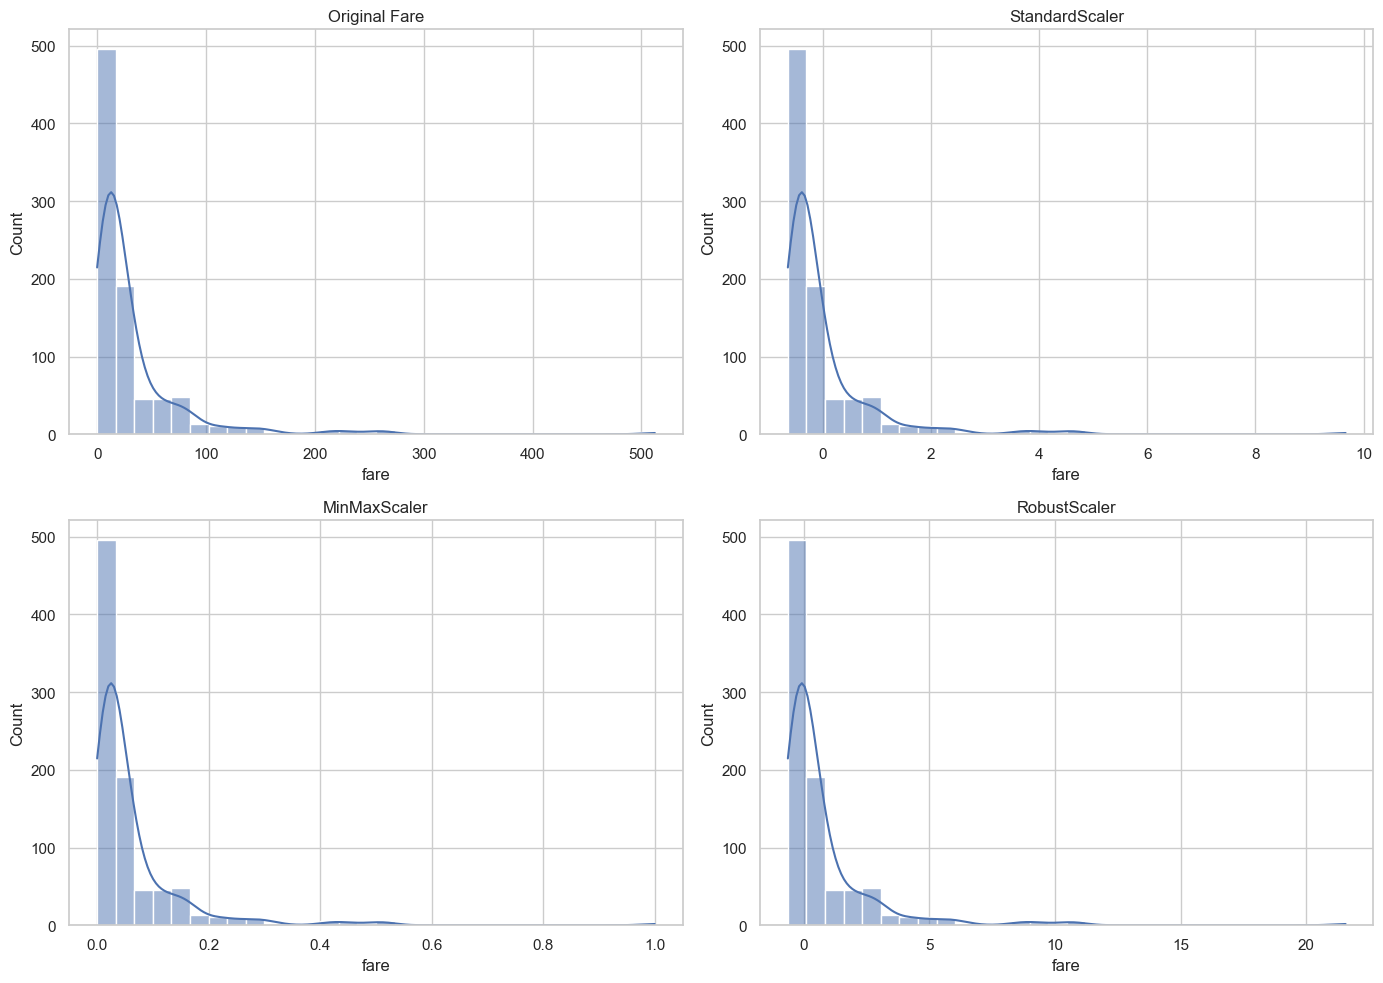

In [14]:
# (tùy chọn) code cho phần Bonus
from sklearn.preprocessing import MinMaxScaler
fare = df[["fare"]].dropna()
standard = StandardScaler()
minmax = MinMaxScaler()
robust = RobustScaler()
fare_standard = standard.fit_transform(fare)
fare_minmax = minmax.fit_transform(fare)
fare_robust = robust.fit_transform(fare)
fare_standard = pd.DataFrame(fare_standard, columns=["fare"])
fare_minmax = pd.DataFrame(fare_minmax, columns=["fare"])
fare_robust = pd.DataFrame(fare_robust, columns=["fare"])

plt.figure(figsize=(14,10))
plt.subplot(2,2,1)
sns.histplot(fare["fare"], bins=30, kde=True)
plt.title("Original Fare")
plt.subplot(2,2,2)
sns.histplot(fare_standard["fare"], bins=30, kde=True)
plt.title("StandardScaler")
plt.subplot(2,2,3)
sns.histplot(fare_minmax["fare"], bins=30, kde=True)
plt.title("MinMaxScaler")
plt.subplot(2,2,4)
sns.histplot(fare_robust["fare"], bins=30, kde=True)
plt.title("RobustScaler")
plt.tight_layout()
plt.show()

### Nhận xét

- Dữ liệu `fare` ban đầu lệch phải rất mạnh và có nhiều outlier.
- **StandardScaler** chuẩn hóa dữ liệu về trung bình 0 và độ lệch chuẩn 1, nhưng vẫn bị ảnh hưởng đáng kể bởi các outlier vì sử dụng mean.
- **MinMaxScaler** đưa dữ liệu về khoảng [0, 1], tuy nhiên các outlier làm phần lớn dữ liệu bị nén gần 0 nên không cải thiện nhiều phân bố.
- **RobustScaler** sử dụng median và IQR nên ít bị ảnh hưởng bởi outlier, giữ được sự phân tán của phần lớn dữ liệu tốt hơn.

**Kết luận:** Với dữ liệu `fare` có phân phối lệch phải và nhiều outlier, **RobustScaler** là lựa chọn phù hợp nhất.

---
## Bảng tự kiểm trước khi nộp

- [X] Notebook chạy **Restart & Run All** không lỗi.
- [X] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [X] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [X] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [X] Đã trả lời tất cả các phần *"Trả lời:"*.
- [X] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [X] Đã push lên **repo cá nhân trên GitHub**.
